In [3]:
import pandas as pd
import seaborn as sns

In [13]:
import pickle
dict_blocks = '../key_files/blocks_snpsid_dict.pkl'

with open(dict_blocks, 'rb') as file:
    dict_blocks = pickle.load(file)

In [14]:
dict_blocks['2_1265']

['2_11533904',
 '2_11533924',
 '2_11533937',
 '2_11533944',
 '2_11533991',
 '2_11533994',
 '2_11534005',
 '2_11534015',
 '2_11534022',
 '2_11534023',
 '2_11534030',
 '2_11534048',
 '2_11534063',
 '2_11534092',
 '2_11534094',
 '2_11534099',
 '2_11534102',
 '2_11534143',
 '2_11534161',
 '2_11534165',
 '2_11534224',
 '2_11534244',
 '2_11534263']

In [11]:
haplotypes = pd.read_csv('/home/tbellagio/HapFM/output_2_block_names.txt',header=None)

In [16]:
haplotypes[haplotypes[0].str.contains('11533904')]

,0
1265,2@11533904-11534263


In [17]:
haplotype_name = '2@11533904-11534263'

In [110]:
haplotype_matrix = pd.read_csv('/home/tbellagio/HapFM/output_2_haplotypeDM.txt', sep = '\t')

In [111]:
haplotype_clusters = [i for i  in haplotype_matrix.columns if '2@11533904-11534263' in i]

In [112]:
clusters_2_1265 = haplotype_matrix[haplotype_clusters]

In [113]:
clusters_2_1265 = clusters_2_1265.replace(1, 2)

In [114]:
#
#training_accessions = '/carnegie/nobackup/scratch/xwu/grenet/climate_prs/1001g/hapfm/training_accessions.txt'

#climate_1001g = '/carnegie/nobackup/scratch/xwu/grenet/climate_prs/1001g/hapfm/pheno_training/bio1.txt'

In [115]:
clim1001 = pd.read_csv('../key_files/1001g_regmap_grenet_ecotype_info_corrected_bioclim_2024May16.csv')

In [4]:
g1001 = pd.read_csv('../gwas/1001g/1001g_grenet_climate.fam',header=None, sep = ' ')

In [6]:
g1001.to_csv('g1001.fam')

In [117]:
climate_1001g = g1001.merge(clim1001, left_on = 0, right_on = 'ecotypeid')[['ecotypeid', 'bio1']]

In [118]:
clusters_2_1265 = clusters_2_1265.set_index(climate_1001g['ecotypeid'])

In [119]:
climate_1001g = climate_1001g.set_index('ecotypeid')

In [120]:
climate_1001g

,bio1
ecotypeid,
10001,9.166667
10002,8.879167
10004,10.358334
10005,9.866667
10006,11.320833
...,...
100002,15.100000
6939,18.333334
9940,13.279166


In [126]:
clusters_2_1265 = clusters_2_1265.replace(2,1)

In [127]:
# Step 2: Prepare the data for logistic regression
df = pd.DataFrame({
    'bio1': climate_1001g['bio1'],
    'cluster_variant1': clusters_2_1265['2@11533904-11534263_1'],
    'cluster_variant2': clusters_2_1265['2@11533904-11534263_2'],
    'cluster_variant3': clusters_2_1265['2@11533904-11534263_3']
})

Optimization terminated successfully.
         Current function value: 0.173751
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.197228
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.322431
         Iterations 6


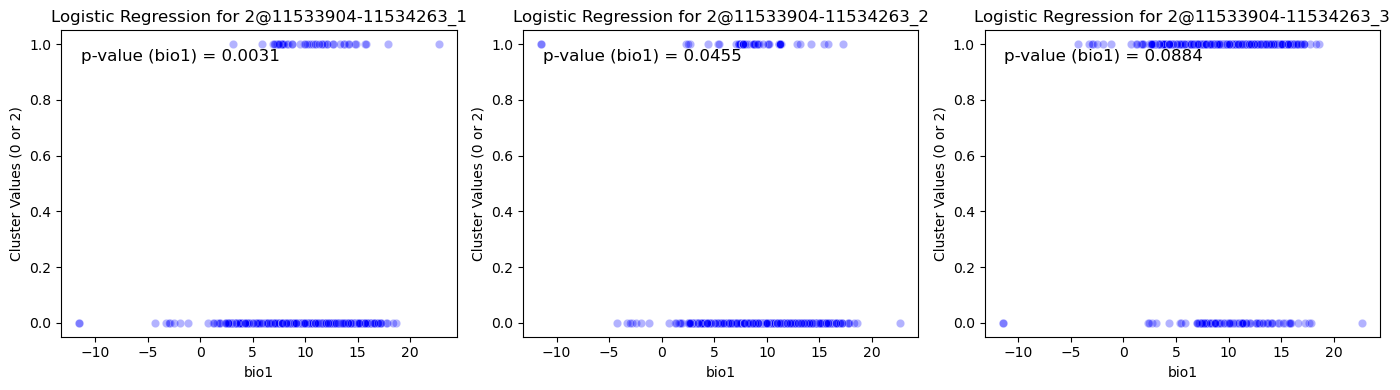

In [133]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# List of variants you want to analyze
variants = ['2@11533904-11534263_1', '2@11533904-11534263_2', '2@11533904-11534263_3']

# Create subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Iterate over the variants and plot each on a different subplot
for i, variant in enumerate(variants):
    # Prepare the data for logistic regression
    X = df['bio1']
    y = clusters_2_1265[variant]

    # Add a constant to the predictor (required by statsmodels)
    X_const = sm.add_constant(X)

    # Fit the logistic regression model using statsmodels
    logit_model = sm.Logit(y, X_const)
    result = logit_model.fit()

    # Extract p-value for the bio1 coefficient
    p_value_bio1 = result.pvalues['bio1']

    # Plot the original data points on the respective subplot
    sns.scatterplot(ax=axes[i], x=df['bio1'], y=clusters_2_1265[variant], color='blue', alpha =0.3)

    # Add p-value to the plot
    axes[i].text(0.05, 0.9, f'p-value (bio1) = {p_value_bio1:.4f}', transform=axes[i].transAxes, fontsize=12, color='black')

    # Set labels and title for each subplot
    axes[i].set_xlabel('bio1')
    axes[i].set_ylabel('Cluster Values (0 or 2)')
    axes[i].set_title(f'Logistic Regression for {variant}')

# Adjust layout for better spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()


In [129]:
forhm = df.sort_values('bio1').set_index('bio1')

<Axes: ylabel='bio1'>

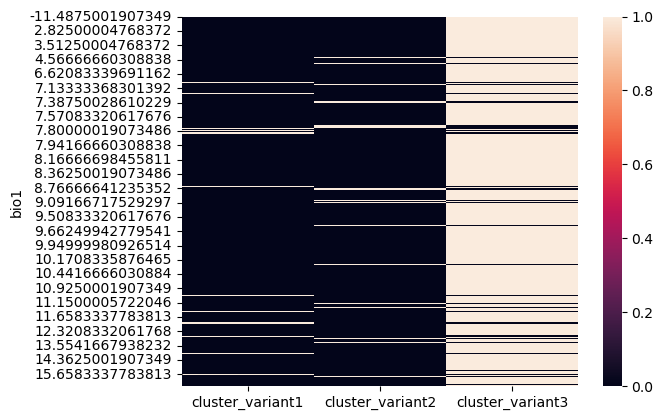

In [130]:
sns.heatmap(forhm)

In [154]:
bio1_cluster1 = df[df['cluster_variant1'] == 1]['bio1'].reset_index()
bio1_cluster1['cluster'] = 1 
bio1_cluster2 = df[df['cluster_variant2'] == 1]['bio1'].reset_index()
bio1_cluster2['cluster'] = 2
bio1_cluster3 = df[df['cluster_variant3'] == 1]['bio1'].reset_index()
bio1_cluster3['cluster'] = 3

In [156]:
cluster_bi01 = pd.concat([bio1_cluster1, bio1_cluster2, bio1_cluster3],axis=0)

In [157]:
cluster_bi01

,ecotypeid,bio1,cluster
0,1925,7.800000,1
1,1954,7.787500,1
2,2202,7.741667,1
3,5486,7.920834,1
4,6019,7.408333,1
...,...,...,...
1019,9998,8.216666,3
1020,9999,9.116667,3
1021,100002,15.100000,3
1022,6939,18.333334,3


<Axes: xlabel='bio1', ylabel='Density'>

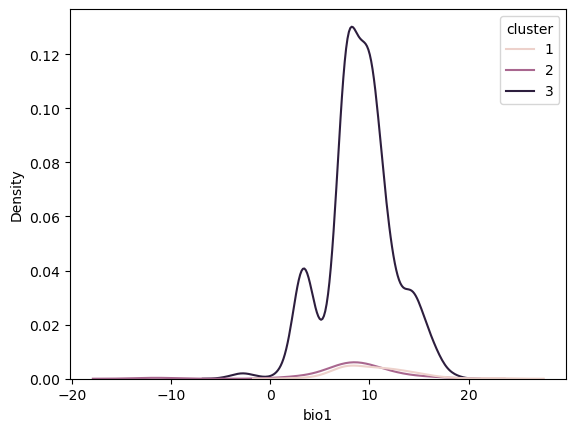

In [161]:
sns.kdeplot(data = cluster_bi01, x = 'bio1', hue = 'cluster') #, hue=clusters_2_1265[variant], multiple='stack', discrete=True)

<Axes: xlabel='bio1', ylabel='Count'>

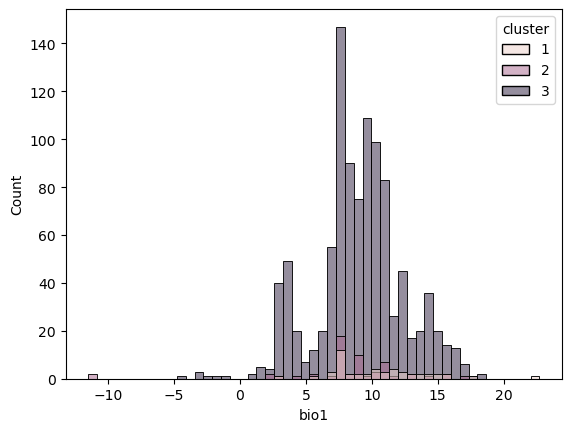

In [162]:
sns.histplot(data = cluster_bi01, x = 'bio1', hue = 'cluster') #, hue=clusters_2_1265[variant], multiple='stack', discrete=True)

<Axes: xlabel='cluster', ylabel='bio1'>

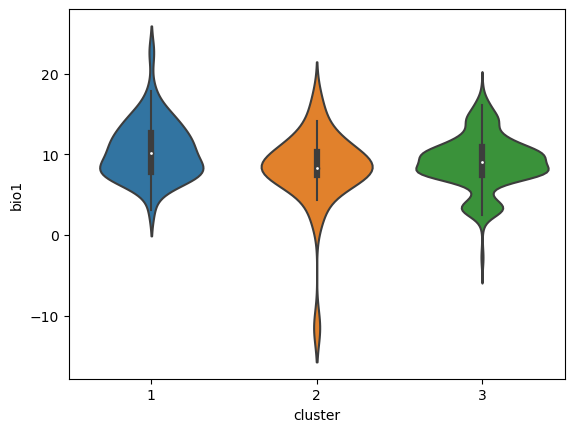

In [168]:
sns.violinplot(data = cluster_bi01, y = 'bio1', x = 'cluster') #, hue=clusters_2_1265[variant], multiple='stack', discrete=True)

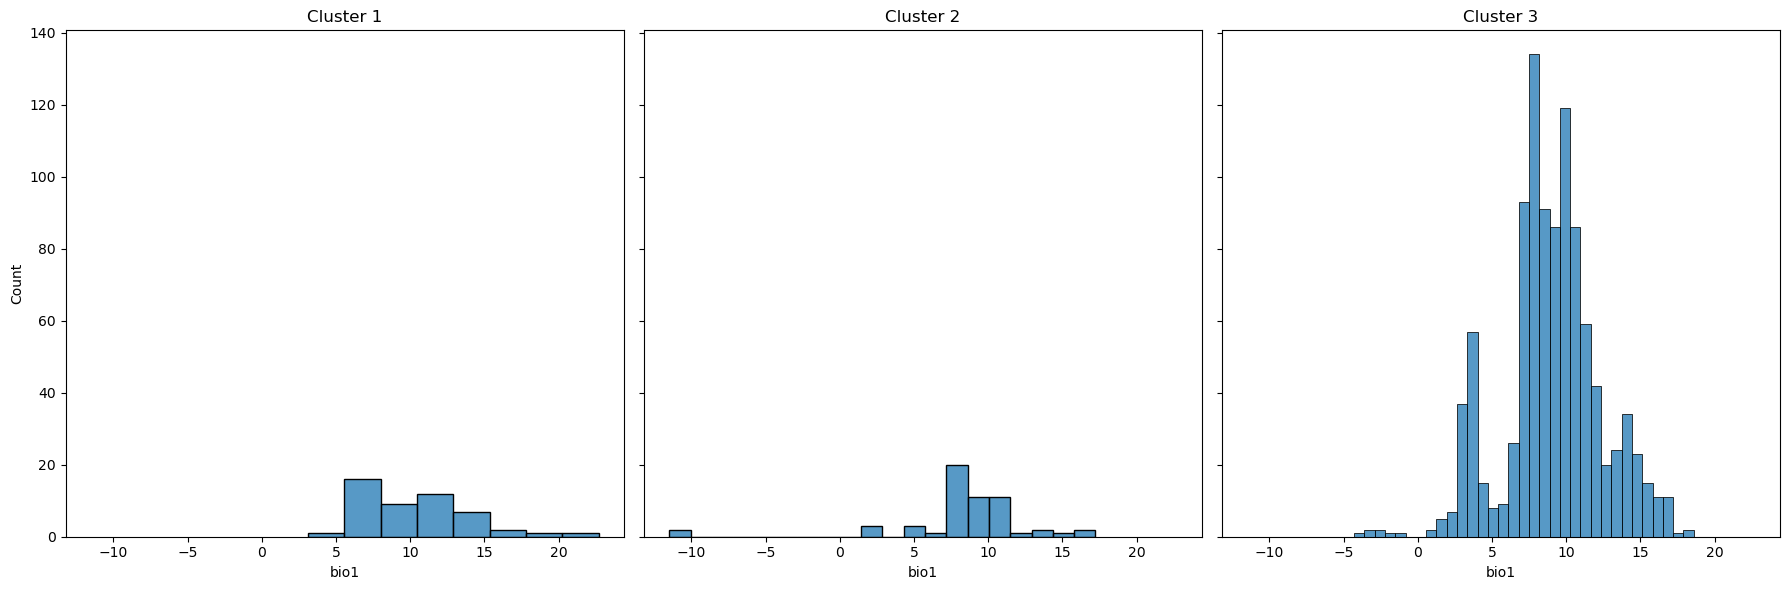

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define the unique values of the 'cluster' (assuming it's 0, 1, and 2 or any three unique values)
unique_clusters = cluster_bi01['cluster'].unique()

# Step 2: Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Step 3: Plot histograms for each unique cluster in separate subplots
for i, cluster_value in enumerate(unique_clusters):
    # Filter data for the current cluster
    cluster_data = cluster_bi01[cluster_bi01['cluster'] == cluster_value]
    
    # Plot the histogram for the current cluster on its respective subplot
    sns.histplot(data=cluster_data, x='bio1', ax=axes[i])
    
    # Set the title for each subplot
    axes[i].set_title(f'Cluster {cluster_value}')
    axes[i].set_xlabel('bio1')
    axes[i].set_ylabel('Count')

# Step 4: Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
    X = df['bio1']
    y = clusters_2_1265[variant]